# EDA on Cleaned PROMISE NASA Combined Dataset

This notebook explores the cleaned combined dataset at `data/processed/promise_nasa_combined_clean.csv`.

Goals:

- Verify the cleaned dataset (shape, dtypes, basic stats).
- Understand global and per-dataset class imbalance.
- Inspect distributions of key complexity and size metrics.
- View correlations between core features to inform feature engineering and model selection.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")

DATA_PATH = "../../data/processed/promise_nasa_combined_clean.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (10566, 23)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,label,dataset
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,1.30,1.30,2.0,2.0,2.0,2.0,1.2,1.2,1.2,1.2,1.4,0,JM1
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,JM1
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,0.38,1279.39,51.0,10.0,8.0,1.0,17.0,36.0,112.0,86.0,13.0,1,JM1
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,1.45,4122.37,129.0,29.0,28.0,2.0,17.0,135.0,329.0,271.0,5.0,1,JM1
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,0.20,572.07,28.0,1.0,6.0,0.0,11.0,16.0,76.0,50.0,7.0,1,JM1


In [30]:
print("\nData types:")
print(df.dtypes)

print("\nLabel distribution (0/1):")
label_counts = df["label"].value_counts().to_frame("count")
label_counts["fraction"] = (label_counts["count"] / label_counts["count"].sum()).round(4)
print(label_counts)

print("\nModules per dataset:")
print(df["dataset"].value_counts())

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
print("\nNumber of numeric features:", len(numeric_cols))
df[numeric_cols].describe().T.head(20)


Data types:
loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64
lOCode               float64
lOComment            float64
lOBlank              float64
locCodeAndComment    float64
uniq_Op              float64
uniq_Opnd            float64
total_Op             float64
total_Opnd           float64
branchCount          float64
label                  int64
dataset                  str
dtype: object

Label distribution (0/1):
       count  fraction
label                 
0       8196    0.7757
1       2370    0.2243

Modules per dataset:
dataset
JM1    8912
KC1    1212
CM1     442
Name: count, dtype: int64

Number of numeric features: 22


,count,mean,std,min,25%,50%,75%,max
loc,10566.0,46.246952,77.807788,1.0,14.0000,26.000,52.0000,3442.00
v(g),10566.0,6.873102,13.271014,1.0,2.0000,4.000,7.0000,470.00
ev(g),10566.0,3.598164,6.895901,1.0,1.0000,1.000,4.0000,165.00
iv(g),10566.0,4.402631,9.339601,1.0,1.0000,2.000,5.0000,402.00
n,10566.0,129.684639,256.000704,0.0,25.0000,62.000,138.0000,8441.00
v,10566.0,767.263074,1994.926957,0.0,96.0000,286.620,731.6125,80843.08
l,10566.0,0.112506,0.140683,0.0,0.0400,0.070,0.1400,2.00
d,10566.0,15.612084,18.724655,0.0,5.1200,10.830,20.4200,418.20
i,10566.0,33.360797,35.459788,0.0,14.9300,25.480,41.2275,569.78
e,10566.0,40244.271501,441700.033618,0.0,524.8625,3198.835,14345.0575,31079782.27


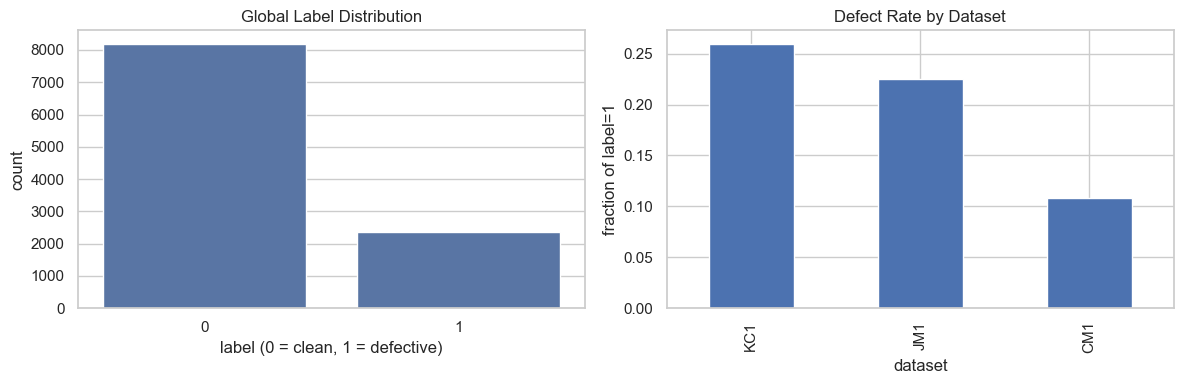

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Global label distribution
sns.countplot(x="label", data=df, ax=axes[0])
axes[0].set_title("Global Label Distribution")
axes[0].set_xlabel("label (0 = clean, 1 = defective)")
axes[0].set_ylabel("count")

# Per-dataset defect rate
label_rate = (
    df.groupby("dataset")["label"]
    .mean()
    .sort_values(ascending=False)
)
label_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Defect Rate by Dataset")
axes[1].set_ylabel("fraction of label=1")
axes[1].set_xlabel("dataset")

plt.tight_layout()
plt.savefig("../../figures/eda_label_balance_clean.png", dpi=150, bbox_inches="tight")
plt.show()

Key features present: ['loc', 'v(g)', 'ev(g)', 'iv(g)']


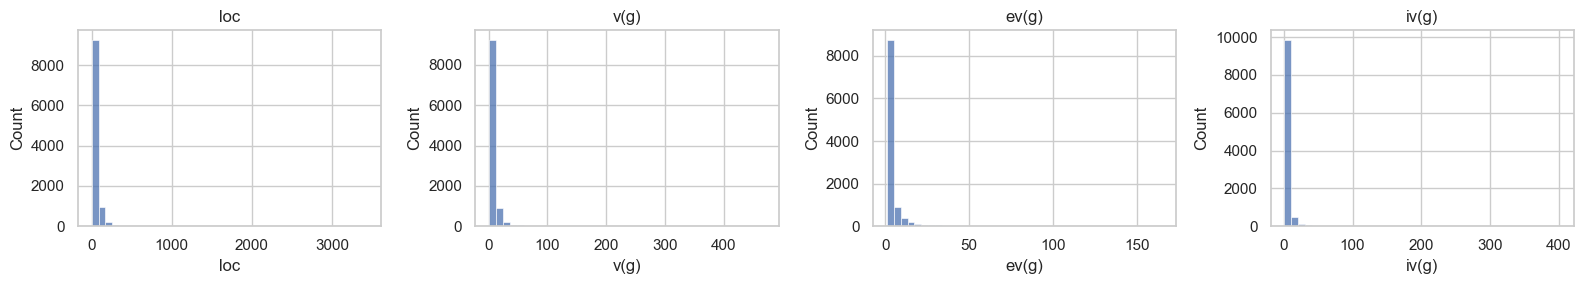

In [32]:
key_features = [
    "loc",    # size
    "v(g)",   # cyclomatic complexity
    "ev(g)",  # essential complexity
    "iv(g)",  # design complexity
]

existing_keys = [f for f in key_features if f in df.columns]
print("Key features present:", existing_keys)

fig, axes = plt.subplots(1, len(existing_keys), figsize=(4 * len(existing_keys), 3))
if len(existing_keys) == 1:
    axes = [axes]

for ax, col in zip(axes, existing_keys):
    sns.histplot(df[col], bins=40, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.savefig("../../figures/eda_key_feature_hists_clean.png", dpi=150, bbox_inches="tight")
plt.show()

Number of numeric features used in correlation: 21


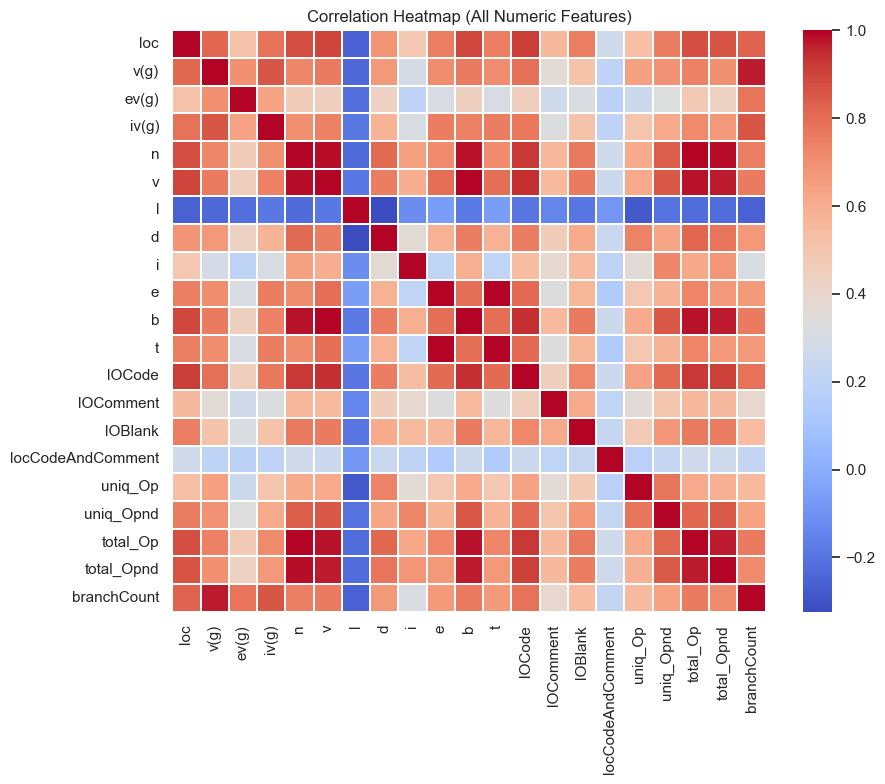

In [33]:
# Correlation heatmap for all numeric features (except label)

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != "label"]
print("Number of numeric features used in correlation:", len(feature_cols))

plt.figure(figsize=(min(1 + 0.4 * len(feature_cols), 20), 8))
cor = df[feature_cols].corr()
sns.heatmap(cor, annot=False, cmap="coolwarm", linewidths=0.3)
plt.title("Correlation Heatmap (All Numeric Features)")
plt.tight_layout()
plt.savefig("../../figures/eda_corr_all_features_clean.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
summary = (
    df.groupby("dataset")
    .agg(
        n_modules=("label", "size"),
        defect_rate=("label", "mean"),
        loc_median=("loc", "median"),
        vg_median=("v(g)", "median"),
    )
    .sort_values("defect_rate", ascending=False)
)

summary["defect_rate"] = summary["defect_rate"].round(3)
summary

,n_modules,defect_rate,loc_median,vg_median
dataset,,,,
KC1,1212,0.260,19.0,2.0
JM1,8912,0.225,27.0,4.0
CM1,442,0.109,19.0,3.0
